In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as bplt
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
class EmbDataset(Dataset):
    def __init__(self, emb):
        self.emb = emb

    def __len__(self):
        return len(self.emb)

    def __getitem__(self, i):
        return self.emb[i]

In [2]:
class LambdaSet(Dataset):
    def __init__(self, X_train, X_test, y_train, y_test, train=True):
        if train:
            self.x_data, self.y_data = X_train, y_train
        else:
            self.x_data, self.y_data = X_test, y_test
    
    def __getitem__(self, i):
        return self.x_data[i], self.y_data[i]

    def __len__(self):
        return self.y_data.shape[0]

In [63]:
class LambdaNet(nn.Module):
    def __init__(self, input_dim):
        super(LambdaNet, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(),

            nn.Linear(256, 128),
            nn.LeakyReLU(),

            nn.Linear(128, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 1),
            nn.Softplus(),
        )

    def forward(self, x):
        return self.layers(x) 


In [78]:

class LambdaNetTrainer:
    """
    Trainer class for the LambdaNet model.
    Handles training, validation, and prediction for lambda regression.
    """

    def __init__(
        self,
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
        idx: np.ndarray,
        embeddings: torch.Tensor,
        lambdas: torch.Tensor,
        flag: np.ndarray,
        per_device_batch_size_lambdanet: int,
        dtype: torch.dtype = torch.float32,
        **kwargs,
    ):
        """
        Initialize the LambdaNet trainer.

        Args:
            model (torch.nn.Module): The LambdaNet regression model.
            optimizer (torch.optim.Optimizer): Optimizer used for parameter updates.
            idx (np.ndarray): Array of global IDs for each embedding sample.
            embeddings (torch.Tensor): Embeddings aligned with idx.
            lambdas (torch.Tensor): Target lambda values corresponding to embeddings.
            flag (np.ndarray): Indicator array, where `flag[i] >= 1` means the sample (with global ID `i`) was seen/trained by the model, and `< 1` means unseen.
            per_device_batch_size_lambdanet (int): Batch size per device for lambdanet trainer.
            dtype (torch.dtype, optional): Dtype of the pad_mask. Defaults to torch.float32.

        Attributes:
            trained_idx (np.ndarray): Subset of idx where flag >= 1.
            trained_emb (torch.Tensor): Embeddings of trained samples.
            trained_lambdas (torch.Tensor): Lambda values of trained samples.
            untrained_idx (np.ndarray): Subset of idx where flag < 1.
            untrained_emb (torch.Tensor): Embeddings of unseen samples.
        """
        self.model = model
        self.optimizer = optimizer
        self.scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)
        self.per_device_batch_size = per_device_batch_size_lambdanet

        self.trained_idx = idx[flag[idx] >= 1]
        self.trained_emb = embeddings[flag[idx] >= 1].to(device=device, dtype=dtype)
        self.trained_lambdas = lambdas[flag[idx] >= 1].to(device=device, dtype=dtype)

        self.untrained_idx = idx[flag[idx] < 1]
        self.untrained_emb = embeddings[flag[idx] < 1].to(device=device, dtype=dtype)

    def train(self, dataloader: DataLoader) -> float:
        self.model.train()
        total_loss = 0.0

        for x, y in dataloader:
            self.optimizer.zero_grad()
            out = self.model(x)
            loss = F.mse_loss(out.squeeze(), y.squeeze())
            loss.backward()
            total_loss += loss.item()
            self.optimizer.step()

        return total_loss / len(dataloader)

    def validate(self, dataloader: DataLoader) -> float:
        self.model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for x, y in dataloader:
                out = self.model(x)
                loss = F.mse_loss(out.squeeze(), y.squeeze())
                total_loss += loss.item()

        return total_loss / len(dataloader)

    def predict(self) -> tuple[list[int], list[float]]:
        loader_te = DataLoader(
            EmbDataset(self.untrained_emb), 
            batch_size=self.per_device_batch_size,
            shuffle=False,
            drop_last=False
        )

        self.model.eval()
        lambda_pred = []

        with torch.no_grad():
            for x in loader_te:
                out = self.model(x)
                lambda_pred += out.squeeze().cpu().tolist()

        self.lambda_pred = np.array(lambda_pred)
        
        return self.lambda_pred

    def reconstruct_lambdas(self, pred_lambdas: list[float]) -> np.ndarray:
        full_lambdas = np.zeros(len(self.trained_idx) + len(self.untrained_idx), dtype=float)

        # Use true lambda to fill trained and pred lambda to fill untrained samples
        full_lambdas[self.trained_idx] = self.trained_lambdas.float().cpu().numpy()
        full_lambdas[self.untrained_idx] = self.lambda_pred

        return torch.tensor(full_lambdas)

    def get_lambdas(
        self,
        val_size: float = 0.2,
        seed: int = 42,
        max_epochs: int = 40,
        print_every: int = 1,
        **kwargs,
    ) -> torch.nn.Module:
        X_train, X_val, y_train, y_val = train_test_split(
            self.trained_emb, self.trained_lambdas, test_size=val_size, random_state=seed
        )
        # scaler = MinMaxScaler()
        # y_train = scaler.fit_transform(y_train.reshape(-1, 1))
        # y_val = scaler.transform(y_val.reshape(-1, 1))
        # y_train = torch.tensor(y_train, dtype=torch.float32)
        # y_val = torch.tensor(y_val, dtype=torch.float32)
        
        loader_tr = DataLoader(
            LambdaSet(X_train, X_val, y_train, y_val, train=True),
            batch_size=self.per_device_batch_size,
            shuffle=True,
            drop_last=True,
        )
        loader_val = DataLoader(
            LambdaSet(X_train, X_val, y_train, y_val, train=False),
            batch_size=self.per_device_batch_size,
            shuffle=True,
            drop_last=True,
        )

        best_model = None
        best_val_loss = float("inf")

        for epoch in range(max_epochs):
            train_loss = self.train(loader_tr)
            val_loss = self.validate(loader_val)
            self.scheduler.step()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                # Keep the best model based on val loss
                best_model = deepcopy(self.model)

            if epoch % print_every == 0:
                print(
                    f"[Epoch {epoch:03d}] Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}",
                    flush=True,
                )

        self.model = best_model

        pred_lambdas = self.predict()
        # pred_lambdas = scaler.inverse_transform(pred_lambdas.reshape(-1, 1)).flatten()

        full_lambdas = self.reconstruct_lambdas(pred_lambdas)

        return full_lambdas



In [65]:
# rd1 and rd2
emb1 = torch.from_numpy(np.load('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-01-10/lambdanet/embeddings.npy'))
lambda1 = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-01-10/lambdanet/lambdas.csv')

emb2 = torch.from_numpy(np.load('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-39-51/lambdanet/embeddings.npy'))
lambda2 = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-39-51/lambdanet/lambdas.csv')

print(f'test1: shape of emb: {emb1.shape}, shape of lambdas: {lambda1.shape}')
print(f'test2 shape of emb: {emb2.shape}, shape of lambdas: {lambda2.shape}')

FileNotFoundError: [Errno 2] No such file or directory: '/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-17-23-01-10/lambdanet/embeddings.npy'

In [83]:
model = LambdaNet(input_dim=320)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
idx_order = lambda1['idx']
flag = lambda1['flag']
lambdas = torch.tensor(lambda1['lambdas'])

In [84]:
lambdanet_trainer = LambdaNetTrainer(
    model=model, 
    optimizer=optimizer, 
    device=torch.device("cpu"), 
    idx=idx_order, 
    embeddings=emb1, 
    lambdas=lambdas, 
    flag=flag, 
    dtype=torch.float32,
    per_device_batch_size_lambdanet=256,
)
lambdas = lambdanet_trainer.get_lambdas()

[Epoch 000] Train MSE: 0.036160 | Val MSE: 0.000341
[Epoch 001] Train MSE: 0.000308 | Val MSE: 0.000286
[Epoch 002] Train MSE: 0.000262 | Val MSE: 0.000243
[Epoch 003] Train MSE: 0.000229 | Val MSE: 0.000220
[Epoch 004] Train MSE: 0.000215 | Val MSE: 0.000212
[Epoch 005] Train MSE: 0.000210 | Val MSE: 0.000209
[Epoch 006] Train MSE: 0.000207 | Val MSE: 0.000207
[Epoch 007] Train MSE: 0.000206 | Val MSE: 0.000206
[Epoch 008] Train MSE: 0.000205 | Val MSE: 0.000205
[Epoch 009] Train MSE: 0.000205 | Val MSE: 0.000205
[Epoch 010] Train MSE: 0.000204 | Val MSE: 0.000205
[Epoch 011] Train MSE: 0.000204 | Val MSE: 0.000204
[Epoch 012] Train MSE: 0.000204 | Val MSE: 0.000204
[Epoch 013] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 014] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 015] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 016] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 017] Train MSE: 0.000203 | Val MSE: 0.000204
[Epoch 018] Train MSE: 0.000203 | Val MSE: 0.000203
[Epoch 019] 

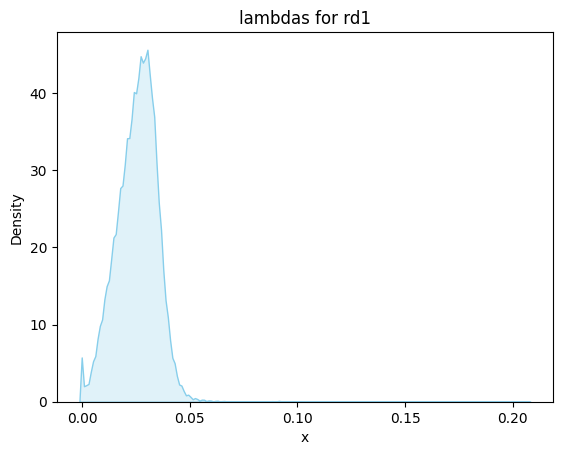

In [85]:
sns.kdeplot(lambdas, fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas for rd1")
plt.show()

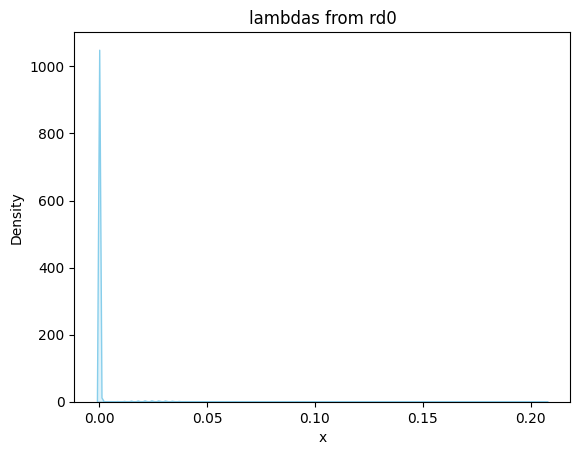

In [8]:
sns.kdeplot(lambda1['lambdas'], fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas from rd0")
plt.show()

In [13]:
lambda1['flag'].value_counts() 
# 7000 steps overfit
# 1000 steps on 10% uniref50 --> 8% trained
# 2000 steps on 10% uniref50 --> 16% trained

flag
0.0    5683580
1.0     512000
Name: count, dtype: int64

In [16]:
lambda1.describe()

,idx,flag,lambdas
count,6.195580e+06,6.195580e+06,6.195580e+06
mean,3.097790e+06,8.263956e-02,1.985742e-03
std,1.788510e+06,2.753367e-01,8.014186e-03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.548895e+06,0.000000e+00,0.000000e+00
50%,3.097790e+06,0.000000e+00,0.000000e+00
75%,4.646684e+06,0.000000e+00,0.000000e+00
max,6.195579e+06,1.000000e+00,2.068750e-01


In [86]:
lambda1.loc[lambda1['lambdas'] == 0, :]                                                                                                                                                                                                                                                                                                                                                               


,idx,flag,lambdas
13382,13382,1.0,0.0
14962,14962,1.0,0.0
16086,16086,1.0,0.0
16406,16406,1.0,0.0
16513,16513,1.0,0.0
...,...,...,...
6195575,6195575,0.0,0.0
6195576,6195576,0.0,0.0
6195577,6195577,0.0,0.0
6195578,6195578,0.0,0.0


In [2]:
import pandas as pd
df = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-22-00-43-42/lambdas_pred.csv')

In [3]:
df['pred_lambda'].isna().sum()

0

In [4]:
df.describe()

,pred_lambda
count,6.195580e+06
mean,2.136854e-02
std,1.353314e-02
min,0.000000e+00
25%,1.182864e-02
50%,2.140160e-02
75%,2.980759e-02
max,3.678997e-01


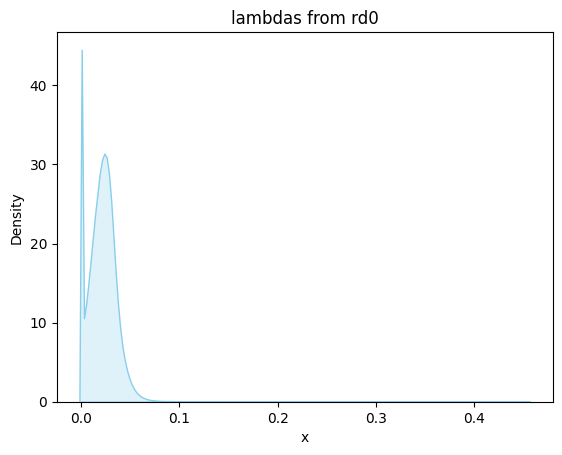

In [8]:
sns.kdeplot(df['pred_lambda'], fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas from rd0")
plt.show()

In [10]:
import pandas as pd
from tqdm import tqdm

lengths = []
idxs = []

with open('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/uniref/mila/uniref50_train.csv', 'r') as infile:
    header = next(infile)
    i = 0
    for line in tqdm(infile):
        fields = line.strip().split(',')
        seq = fields[-1]               # assuming sequence is last column
        lengths.append(len(seq))
        idxs.append(i)
        i += 1



61984724it [02:00, 516328.29it/s] 


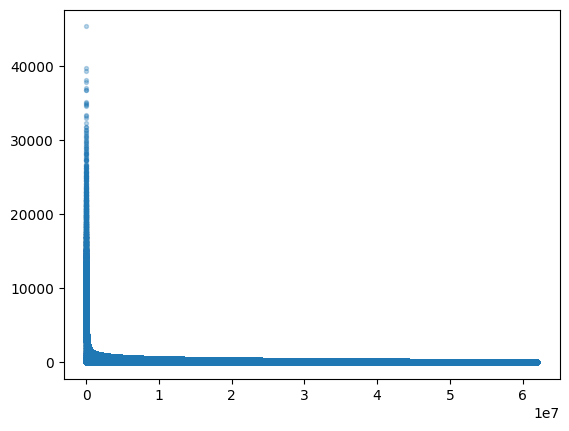

Text(0.5, 1.0, 'AMPLIFY Uniref 50 dataset')

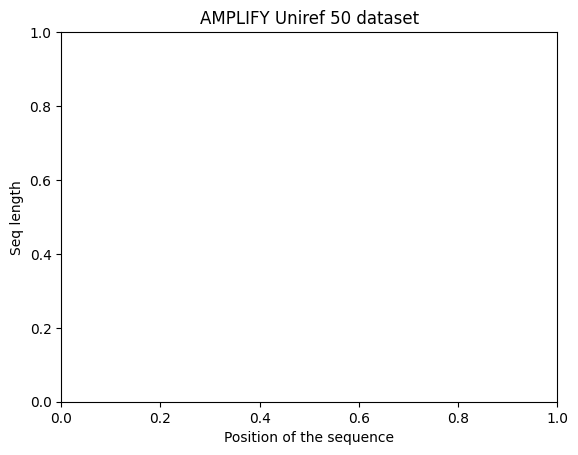

In [12]:
plt.scatter(idxs, lengths, s=8, alpha=0.3, c='tab:blue')
plt.show()
plt.xlabel('Position of the sequence')
plt.ylabel('Seq length')
plt.title('AMPLIFY Uniref 50 dataset')

In [2]:

df = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/uniref/mila/uniref50_train_0.1.csv')
df['length'] = df['sequence'].apply(lambda x: len(x))
df['idx'] = df.index

# use pred lambda for the next round and get the lambdas in l
l = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-22-02-48-20/lambdas.csv')
p = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-10-22-01-54-58/lambdas_pred.csv')
p['idx'] = p.index

m = pd.merge(df, l, on='idx',how='inner')
tmp = pd.merge(m, p, on='idx',how='inner')
tmp

,name,sequence,length,idx,flag,lambdas,pred_lambda
0,>UniRef50_A0A7K3XY34 LPXTG cell wall anchor do...,MSKPNDHITEASTPAANHTETRFEDVATAAVAAAAEAEAAAAAAAA...,34987,0,2.0,0.058099,0.091657
1,>UniRef50_A0A3N0YXI7 Titin n=4 Tax=Xenocypridi...,MSTEGDAGGQPSTTTISTVAVQAGDAQIVVAVLKCGELVHLQLIEA...,34580,1,2.0,0.055168,0.087670
2,>UniRef50_A0A9P1FFJ3 Polyketide synthase n=1 T...,MGQPHTSQPRRAVAEGPPLEPRPEAVRTLPQWLICAASDAPEAGIV...,33271,2,2.0,0.094467,0.092565
3,>UniRef50_A0A8P4FY84 Titin n=6 Tax=Clupeocepha...,MSTQAPTFIQPLQSVVALEGSAATFEAQVSGSPVPEVSWFRDGQVL...,25876,3,2.0,0.085965,0.092349
4,>UniRef50_A0A8J1Z4Q2 Peptidase S74 domain-cont...,MKQPPDWEHPTAASGSSWDVRSPRRRRRKSTLHPSEEIEELEAELM...,28837,4,2.0,0.087004,0.094290
...,...,...,...,...,...,...,...
6195575,>UniRef50_A0A7G8ZX00 Myxovirus resistance D (F...,MQSEAVQVSST,11,6195575,2.0,0.035974,0.000507
6195576,>UniRef50_A0A2P4SAF8 Uncharacterized protein n...,MLHFLCLQLVH,11,6195576,2.0,0.033304,0.000072
6195577,>UniRef50_Q9G5X4 Cytochrome c oxidase subunit ...,MSTMTRWFLSM,11,6195577,2.0,0.033409,0.000063
6195578,>UniRef50_Q8WD05 Cytochrome c oxidase subunit ...,MSTINRWFLST,11,6195578,2.0,0.014905,0.009538


In [4]:
p.describe()

,pred_lambda,idx
count,6.195580e+06,6.195580e+06
mean,2.148231e-02,3.097790e+06
std,1.340263e-02,1.788510e+06
min,0.000000e+00,0.000000e+00
25%,1.200645e-02,1.548895e+06
50%,2.159881e-02,3.097790e+06
75%,2.996275e-02,4.646684e+06
max,3.235503e-01,6.195579e+06


In [3]:
tmp.sort_values(by='lambdas', ascending=False)


,name,sequence,length,idx,flag,lambdas,pred_lambda
1563931,>UniRef50_A0A2G9XBN3 Uncharacterized protein n...,MNILLCYVTPYSLIAVLNGDKTVRVKFPYPAFFDNYSDIWESVYGE...,352,1563931,1.0,37840.951279,0.013025
2560837,>UniRef50_UPI001455BEF2 uncharacterized protei...,MRPDSHAASFRMRPDSHAASFRMRPDSHAAGFRMRPDSHAASFRMR...,241,2560837,2.0,35092.570289,0.000000
3408786,>UniRef50_A0A7V3E4L2 Glycosyltransferase famil...,MLSIKKQYGIKTDFILIVGHSHPVKNFTGVIEALKIVLKKHKVKLV...,176,3408786,1.0,34685.672561,0.016279
2869179,>UniRef50_A0A6C0BJV9 Methyltransferase n=1 Tax...,MITEVDVGDVEYHRRAIKGMITAQKQRDPSFTVIDVGGSMDGWSTD...,215,2869179,1.0,34109.976008,0.000000
1636204,>UniRef50_A0A847F4J1 EF-hand domain-containing...,MNLRRAIMQRLLFIFAISILLVACAEEKEEPGRIDFDGKVPNFDGI...,342,1636204,1.0,33955.230479,0.000000
...,...,...,...,...,...,...,...
462957,>UniRef50_A0A2H5W5R8 Beta-barrel assembly-enha...,MRFAIRYSPFAVRHLPFAILVGLFLGAWAILGMTLAFAQEATASDP...,671,462957,1.0,0.000000,0.004813
462958,>UniRef50_A0A2T5G6C7 non-specific serine/threo...,MKSGDVVGGRYLIRRKLGEGGMSFVYLAEDLLLGRNVAIKVLREPY...,671,462958,1.0,0.000000,0.026336
5205513,>UniRef50_A0A429DPY7 Recombinase zinc beta rib...,MYLFRGLIRCAACERKMKGSPRKYGMYYRCPARTLTLALLTHPPTI...,85,5205513,1.0,0.000000,0.033303
5205517,>UniRef50_A0A2A9F0Y0 Uncharacterized protein n...,MAAAYKVLGDGPGPALAAYAVGLGAAVGAAVLLHRWVERPAIRLSR...,85,5205517,1.0,0.000000,0.004761


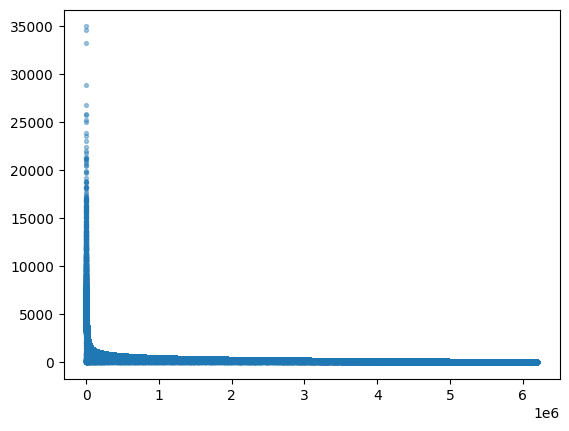

In [8]:
plt.scatter(df.index, df['length'], s=8, alpha=0.4, c='tab:blue')
plt.show()
plt.xlabel('Position of the sequence in the dataset')

In [19]:
df.describe()

,length
count,6.195580e+06
mean,2.830203e+02
std,3.295929e+02
min,1.100000e+01
25%,1.080000e+02
50%,1.940000e+02
75%,3.470000e+02
max,3.498700e+04


In [15]:
df.loc[df['length']<=100, :]

,name,sequence,length
37,>UniRef50_S4R6J1 Fibrinogen C-terminal domain-...,AGDSMTYHQGRPFSTVDRDNDLAITNCAVSYHGAWWYKNCHRANLN...,100
80,>UniRef50_A0A699XVK7 Reverse transcriptase dom...,KDGVENVEVIESKPEITEIVDEETKPLPEIEELKPEEATLIPDEAT...,62
127,>UniRef50_A0A356FBV1 Pilus protein (Fragment) ...,SSSSSSSSSSSSSSSSSSSSSSSS,24
595,>UniRef50_A0A6V7JAZ3 Uncharacterized protein (...,LSQLEDLQTSRIVRILTVDFPHYFAVVSRVRQEVHAVGPEGGTVSS...,70
739,>UniRef50_E1NVC8 LPXTG-motif cell wall anchor ...,MFNYQTENPDYTVPNGEAPLGIHQTSQQKQTTDNLSQLEANQRVKA...,88
...,...,...,...
6195575,>UniRef50_A0A7G8ZX00 Myxovirus resistance D (F...,MQSEAVQVSST,11
6195576,>UniRef50_A0A2P4SAF8 Uncharacterized protein n...,MLHFLCLQLVH,11
6195577,>UniRef50_Q9G5X4 Cytochrome c oxidase subunit ...,MSTMTRWFLSM,11
6195578,>UniRef50_Q8WD05 Cytochrome c oxidase subunit ...,MSTINRWFLST,11


In [27]:
import wandb
api = wandb.Api()

# Replace with your actual project path
run = api.run("tecchk-cyt-duke-university/amplify/23qh0gh1")

# Export the logged history as a DataFrame
history = run.history(pandas=True)

In [28]:
history

,uniprot_val_accuracy,uniprot_val_perplexity,pdb_val_loss,uniprot_val_loss,oas_val_perplexity,train_accuracy,num_samples,oas_val_accuracy,slack_mean,num_epochs,...,_step,_timestamp,train_loss,oas_val_loss,learning_rate,pdb_val_accuracy,pdb_val_perplexity,_runtime,num_steps,model_parameters
0,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,...,0,1.760979e+09,NaN,NaN,NaN,NaN,None,1.262174,NaN,7409627.0
1,NaN,None,NaN,NaN,None,0.152484,51200.0,NaN,0.000452,0.0,...,1,1.760979e+09,2.850221,NaN,0.000099,NaN,None,70.754347,100.0,NaN
2,NaN,None,NaN,NaN,None,0.204977,102400.0,NaN,0.000345,0.0,...,2,1.760979e+09,2.629197,NaN,0.000199,NaN,None,129.977556,200.0,NaN
3,NaN,None,NaN,NaN,None,0.206292,153600.0,NaN,0.000305,0.0,...,3,1.760979e+09,2.614787,NaN,0.000299,NaN,None,187.236210,300.0,NaN
4,NaN,None,NaN,NaN,None,0.208576,204800.0,NaN,0.000284,0.0,...,4,1.760979e+09,2.607441,NaN,0.000399,NaN,None,245.375694,400.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,NaN,None,NaN,NaN,None,0.031071,153600.0,NaN,0.105857,2.0,...,128,1.761002e+09,188.846390,NaN,0.000299,NaN,None,15903.043407,300.0,NaN
129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129,1.761008e+09,NaN,NaN,NaN,NaN,NaN,15904.387452,NaN,7409627.0
130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,130,1.761008e+09,NaN,NaN,NaN,NaN,NaN,15905.203389,NaN,7409627.0
131,NaN,NaN,NaN,NaN,NaN,0.152497,51200.0,NaN,0.000452,0.0,...,131,1.761008e+09,2.850214,NaN,0.000099,NaN,NaN,15982.540654,100.0,NaN
